# Segundo TP de ALC 2025

Por: Ignacio Gallardo (409/23) y Tiago Stangalini (50/23)

## Autovectores y Autovalores de $L$ y $R$

### 1a

Sean $A$ la matriz de adyacencia y $K$ la matriz de grado.

Llamemos $\vec{1}$ al vector de todos unos. Queremos ver que:
$$
\begin{itemize}
    \item[(a)] $L \vec{1} = \lambda \vec{1}$
    \item[(b)] $P \vec{1} = \lambda \vec{1}$
\end{itemize}
$$
Empecemos con (a):

$$L \vec{1} = (K - A)\vec{1} = K \vec{1} - A \vec{1}$$

Para la componente $i$ del vector $A \vec{1}$, se tiene:

$$(A \vec{1})_i = \sum_{j=1}^{n} A_{ij} \cdot 1 = \sum_{j=1}^{n} A_{ij}$$

Pero esta suma es simplemente el grado del vértice $i$, es decir, $k_{ii}$ (como ya se vio en el TP).

Como $K$ es diagonal, el producto $K \vec{1}$ da como resultado el vector cuyos elementos son la diagonal de $K$, es decir:

$$K \vec{1} = (k_{11}, k_{22}, \dots, k_{ii})^t$$

donde $k_{ii}$ es el grado del vértice $i$.

Entonces,

$$L \vec{1} = K \vec{1} - A \vec{1} = 
\begin{pmatrix}
k_{11} \\
k_{22} \\
\vdots \\
k_{ii}
\end{pmatrix}
-
\begin{pmatrix}
k_{11} \\
k_{22} \\
\vdots \\
k_{ii}
\end{pmatrix}
=
\vec{0}$$

Luego,

$$L \vec{1} = 0 \cdot \vec{1}$$

Es decir, $\vec{1}$ es autovector de $L$ con autovalor $0$.

Ahora pasamos a (b), para la matriz $P$:

$$R = P - A \quad \text{y queremos ver que} \quad R \vec{1} = \lambda \vec{1}$$

Sabemos que:

$$P \vec{1} = \left( \frac{k_i k_j}{2E} \right)_j \vec{1}$$

Ya vimos que:

$$(A \vec{1})_i = k_{ii}$$

Entonces:

$$(P \vec{1})_i = \sum_{j \in E} \frac{k_i k_j}{2E}
= \frac{k_i}{2E} \sum_{j \in E} k_j
= \frac{k_i}{2E} \cdot 2E = k_i$$

Es decir,

$$P \vec{1} = A \vec{1}$$

Y por lo tanto:

$$R \vec{1} = (P - A)\vec{1} = P \vec{1} - A \vec{1} = \vec{0}$$

Al igual que con $L$.

Finalmente, recordemos que:

$$\Delta = \frac{1}{4} s^t L s$$

Si tomamos $s = \vec{1}$, entonces:

$$\Delta = 0$$

Es decir, no hay ninguna partición en 2 grupos. $\vec{1}$ representa una agrupación nula, o trivial, o como se la quiera llamar. Pero básicamente no divide nada.

SyntaxError: invalid syntax (2062843775.py, line 1)

In [1]:
# Carga de paquetes necesarios para graficar
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Para leer archivos
import geopandas as gpd # Para hacer cosas geográficas
import seaborn as sns # Para hacer plots lindos
import networkx as nx # Construcción de la red en NetworkX
import scipy

##### Carga de funciones del Template

In [2]:
# Importamos las funciones del template
from template_funciones_2 import *

# Pruebas con la matriz base

In [3]:
# Matriz A de ejemplo
A_ejemplo = np.array([
    [0, 1, 1, 1, 0, 0, 0, 0],
    [1, 0, 1, 1, 0, 0, 0, 0],
    [1, 1, 0, 1, 0, 1, 0, 0],
    [1, 1, 1, 0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0, 1, 1, 1],
    [0, 0, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 1, 0, 1],
    [0, 0, 0, 0, 1, 1, 1, 0]
])

A_ejemplo

array([[0, 1, 1, 1, 0, 0, 0, 0],
       [1, 0, 1, 1, 0, 0, 0, 0],
       [1, 1, 0, 1, 0, 1, 0, 0],
       [1, 1, 1, 0, 1, 0, 0, 0],
       [0, 0, 0, 1, 0, 1, 1, 1],
       [0, 0, 1, 0, 1, 0, 1, 1],
       [0, 0, 0, 0, 1, 1, 0, 1],
       [0, 0, 0, 0, 1, 1, 1, 0]])

In [4]:
L = calcula_L(A_ejemplo)

In [5]:
info = np.linalg.eig(L)

print("Autovalores: " + str(info[0][np.argsort(np.abs(info[0]))]))
#print("Autovectores:")
#print(info[1])

Autovalores: [5.66726613e-17 7.63932023e-01 4.00000000e+00 4.00000000e+00
 4.00000000e+00 4.00000000e+00 5.23606798e+00 6.00000000e+00]


In [6]:
mu = 0.000001

info = np.linalg.eig(inversa_desde_LU(L + np.eye(L.shape[0]) * mu))

print("Autovalores: " + str(info[0][np.argsort(np.abs(info[0]))]))
#print("Autovectores:")
#print(info[1])

Autovalores: [1.66666639e-01 1.90982969e-01 2.49999937e-01 2.49999937e-01
 2.49999938e-01 2.49999938e-01 1.30901528e+00 1.00000000e+06]


In [7]:
metpotI(A_ejemplo, mu)

(array([ 8.64150058e-12,  4.95441127e-12,  5.00000000e-01, -5.00000000e-01,
        -5.00000000e-01,  5.00000000e-01,  6.04671230e-12,  7.10744024e-12]),
 3.807283992087468e-12,
 True)

In [8]:
metpotI2(A_ejemplo, mu)

(array([-0.39413193, -0.39407432,  0.30770613,  0.30770613,  0.30770586,
         0.30770586, -0.39413449, -0.39407047]),
 -0.5615505798779664,
 True)

In [9]:
modularidad_iterativo(A_ejemplo)

[[4, 5, 6, 7], [0, 1, 2, 3]]

C:\Users\Igancio\AppData\Local\Temp\ipykernel_24360\4120608376.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(communities))


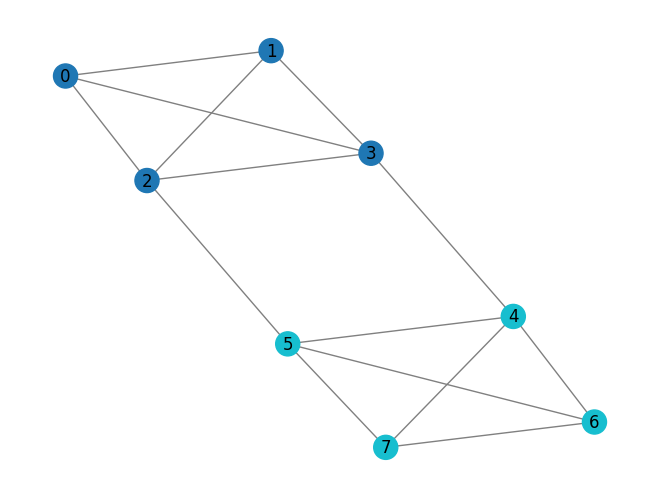

In [10]:
def draw_graph_with_communities(A, communities):
    G = nx.from_numpy_array(A)

    # Assign a unique color to each community
    colors = plt.cm.get_cmap('tab10', len(communities))
    node_colors = [None] * len(A)

    for i, group in enumerate(communities):
        for node in group:
            node_colors[node] = colors(i)

    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, node_color=node_colors, with_labels=True, edge_color='gray')
    plt.show()
    
draw_graph_with_communities(A_ejemplo, modularidad_iterativo(A_ejemplo))

In [11]:
laplaciano_iterativo(A_ejemplo,1)

[[0, 1, 2, 3], [4, 5, 6, 7]]

C:\Users\Igancio\AppData\Local\Temp\ipykernel_24360\1979818445.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(communities))


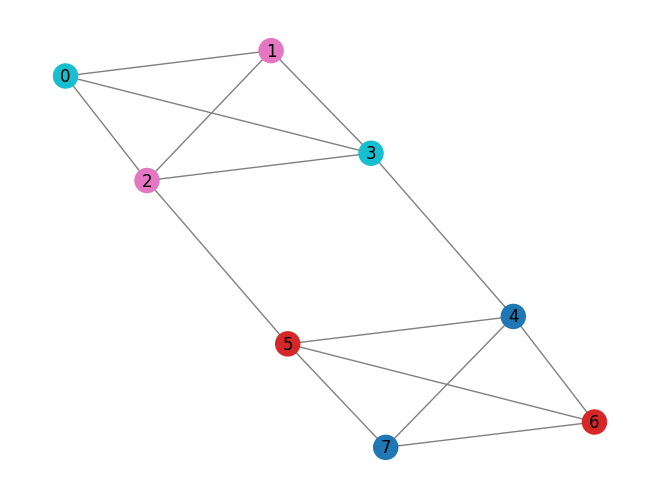

In [12]:
def draw_graph_with_communities(A, communities):
    G = nx.from_numpy_array(A)

    # Assign a unique color to each community
    colors = plt.cm.get_cmap('tab10', len(communities))
    node_colors = [None] * len(A)

    for i, group in enumerate(communities):
        for node in group:
            node_colors[node] = colors(i)

    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, node_color=node_colors, with_labels=True, edge_color='gray')
    plt.show()
    
draw_graph_with_communities(A_ejemplo, laplaciano_iterativo(A_ejemplo,2))

In [13]:
# Leemos el archivo, retenemos aquellos museos que están en CABA, y descartamos aquellos que no tienen latitud y longitud
museos = gpd.read_file('https://raw.githubusercontent.com/MuseosAbiertos/Leaflet-museums-OpenStreetMap/refs/heads/principal/data/export.geojson')
barrios = gpd.read_file('https://cdn.buenosaires.gob.ar/datosabiertos/datasets/ministerio-de-educacion/barrios/barrios.geojson')
nombreMuseos = museos["name"]

In [14]:
# En esta línea:
# Tomamos museos, lo convertimos al sistema de coordenadas de interés, extraemos su geometría (los puntos del mapa),
# calculamos sus distancias a los otros puntos de df, redondeamos (obteniendo distancia en metros), y lo convertimos a un array 2D de numpy
D = museos.to_crs("EPSG:22184").geometry.apply(lambda g: museos.to_crs("EPSG:22184").distance(g)).round().to_numpy()

def construye_adyacencia(D,m):
    # Función que construye la matriz de adyacencia del grafo de museos
    # D matriz de distancias, m cantidad de links por nodo
    # Retorna la matriz de adyacencia como un numpy.
    D = D.copy()
    l = [] # Lista para guardar las filas
    for fila in D: # recorriendo las filas, anexamos vectores lógicos
        l.append(fila<=fila[np.argsort(fila)[m]] ) # En realidad, elegimos todos los nodos que estén a una distancia menor o igual a la del m-esimo más cercano
    A = np.asarray(l).astype(int) # Convertimos a entero
    np.fill_diagonal(A,0) # Borramos diagonal para eliminar autolinks
    return(A)


Veamos el analisis de Ciudades

## Para m = 3 Conexiones

In [15]:
Adyaciencia3 = construye_adyacencia(D, 3)

matriz_Simetrica = simetrizacionDeA(Adyaciencia3)

In [16]:
np.allclose(matriz_Simetrica, matriz_Simetrica.transpose(), atol=1e-8)

True

In [19]:
laplaciano_iterativo(matriz_Simetrica,2)

[[3, 4, 6, 11, 17, 22, 24, 25, 34, 39, 42, 65, 86, 87, 88, 89, 126, 130, 131],
 [1,
  8,
  19,
  26,
  27,
  28,
  29,
  30,
  49,
  50,
  52,
  53,
  55,
  57,
  77,
  79,
  80,
  82,
  84,
  85,
  113],
 [0,
  2,
  5,
  9,
  10,
  12,
  13,
  14,
  15,
  16,
  18,
  21,
  23,
  32,
  35,
  38,
  40,
  43,
  47,
  48,
  56,
  59,
  61,
  63,
  66,
  78,
  83,
  98,
  105,
  107,
  115,
  116,
  118,
  120,
  123,
  124,
  128,
  129,
  133,
  135],
 [7,
  20,
  31,
  33,
  36,
  37,
  41,
  44,
  45,
  46,
  51,
  54,
  58,
  60,
  62,
  64,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  81,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  99,
  100,
  101,
  102,
  103,
  104,
  106,
  108,
  109,
  110,
  111,
  112,
  114,
  117,
  119,
  121,
  122,
  125,
  127,
  132,
  134]]

In [18]:
modularidad_iterativo(matriz_Simetrica)

[[2, 5, 9, 12, 13, 16, 21, 35, 56, 63, 115, 116, 128],
 [0, 10, 14, 15, 18, 40, 59, 61, 78, 98, 107, 118, 123, 124, 135],
 [20,
  31,
  32,
  36,
  37,
  45,
  47,
  48,
  54,
  58,
  60,
  62,
  66,
  70,
  71,
  74,
  76,
  81,
  95,
  96,
  97,
  99,
  100,
  101,
  102,
  103,
  104,
  108,
  109,
  112,
  114,
  119,
  122,
  127,
  134],
 [1,
  3,
  4,
  8,
  19,
  22,
  26,
  27,
  28,
  29,
  30,
  39,
  49,
  50,
  52,
  53,
  55,
  57,
  77,
  79,
  80,
  82,
  84,
  85,
  113],
 [11, 23, 24, 34, 38, 43, 65, 86, 105, 129, 133],
 [6, 17, 25, 42, 87, 88, 89, 126, 130, 131],
 [7, 72, 90, 93, 94, 106, 110, 111, 117, 125, 132],
 [33, 41, 44, 46, 51, 64, 67, 68, 69, 73, 75, 83, 91, 92, 120, 121]]